<a href="https://colab.research.google.com/github/simulate111/Computer-vision2026ABO/blob/main/CompViz_part_I_nr_2_ipynb_txt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IT00CJ11 Computer Vision (5 cr. ECTS), spring 2025

***Direct computational methods and deep learning for vision - Overview***

**Part I, direct methods (cf. Solem)**

- Basic image handling and processing
- Local image descriptors
- Image to image mappings
- Camera models and augmented reality
- Multiple view geometry
- Clustering images
- Searching images
- Classifying image content
- Image segmentation
- OpenCV

**Part II, deep learning (cf. Elgendy)**

- Neural networks
- Convolutional neural networks
- Hyperparameter tuning
- Image classification and detection
- Transfer learning
- Object detection

# **Basic image handling and processing**


**PIL - The *Python Image Library***

The Python Imaging Library (PIL) is used for general image handling and lots of
basic image operations like resizing, cropping, rotating, color conversion and much
more. PIL is free and available from http://www.pythonware.com/products/pil/.
With PIL, you can read images from most formats and write to the most common ones.
The most important module is the Image module. To read an image, use:

In [4]:
from PIL import Image
pil_im = Image.open('roadmap.jpg')

Now, we convert this to grayscale and create a thumbnail:

In [5]:
pil_im = Image.open('roadmap.jpg').convert('L')

In [6]:
pil_im.thumbnail((128,128))

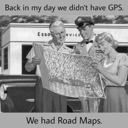

In [7]:
pil_im.save('pil_thumb.jpg')
display(pil_im)
pil_im.show()

The last commands show the difference between inline and file dísplay. See *Solem* for further examples.

**Matplotlib**

Matplotlib is a library for plotting graphs or drawing points, lines, and curves on images. Its graphics has much more powerful features than the plotting available in PIL and can be used for producing high-quality figures. The PyLab interface is a set of functions that allows the user to create plots.

We proceed to check out a few examples

**Images, points and lines**

Although it is possible to create nice bar plots, pie charts, scatter plots, etc., only a few commands are needed for most computer vision purposes. Most importantly, we want to be able to show things like interest points, correspondences, and detected objects using points and lines. Here is an example of plotting an image with a few points and a line:

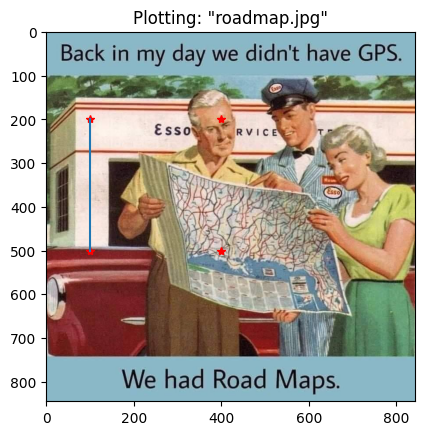

In [8]:
from PIL import Image
from pylab import *
# read image to array
im = array(Image.open('roadmap.jpg'))
# plot the image
imshow(im)
# some points
x = [100,100,400,400]
y = [200,500,200,500]
# plot the points with red star-markers
plot(x,y,'r*')
# line plot connecting the first two points
plot(x[:2],y[:2])
# add title and show the plot
title('Plotting: "roadmap.jpg"')
show()

This plots the image, then four points with red star markers at the x and y coordinates given by the x and y lists, and finally draws a line (blue by default) between the two first points in these lists. Figure 1-2 shows the result. The show() command starts the figure GUI and raises the figure windows. This GUI loop blocks your scripts and they are paused until the last figure window is closed. You should call show() only once per script, usually at the end. Note that PyLab uses a coordinate origin at the top left corner as is common for images. The axes are useful for debugging, but if you want a prettier plot, add:

(np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(1.0))

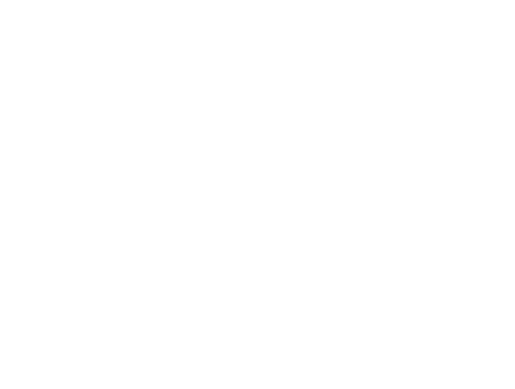

In [9]:
axis('off')

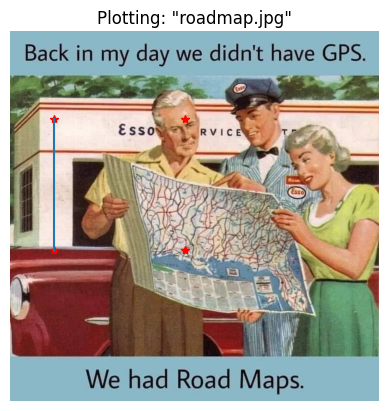

In [10]:
from PIL import Image
from pylab import *
# read image to array
im = array(Image.open('roadmap.jpg'))
# plot the image
imshow(im)
# some points
x = [100,100,400,400]
y = [200,500,200,500]
# plot the points with red star-markers
plot(x,y,'r*')
# line plot connecting the first two points
plot(x[:2],y[:2])
# add title and show the plot
title('Plotting: "roadmap.jpg"')
axis('off') # cf. Solem for further plotting options
show()

**Contours and histograms**

Here's how to visualize image iso-contours:

(np.float64(0.5), np.float64(842.5), np.float64(0.5), np.float64(844.5))

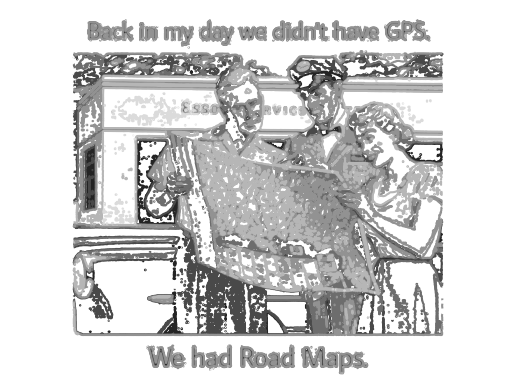

In [11]:
from PIL import Image
from pylab import *
# read image to array
im = array(Image.open('roadmap.jpg').convert('L'))
# create a new figure
figure()
# don't use colors
gray()
# show contours with origin upper left corner
contour(im, origin='image')
axis('equal')
axis('off')

Conversion to gray-scale was done as shown previously. An image histogram is a plot showing the distribution of pixel values. A number of bins is specified for the span of values and each bin gets a count of how many pixels have values in the bin’s range. The visualization of the (graylevel) image histogram is done using the hist() function:

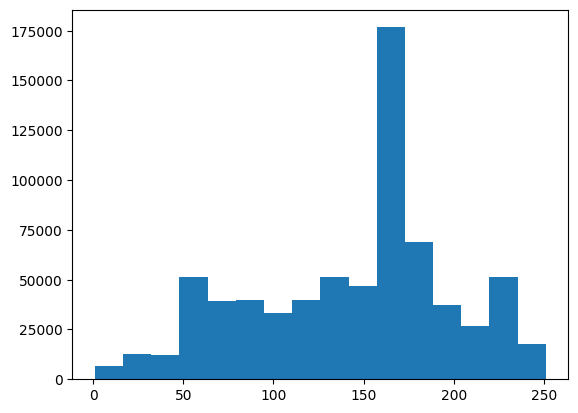

In [12]:
figure()
hist(im.flatten(),16)
show()

The second argument specifies the number of bins to use. Note that the image needs to be flattened first, because hist() takes a one-dimensional array as input. The method flatten() converts any array to a one-dimensional array with values taken row-wise.

**Interactive annotation**

Sometimes users need to interact with an application, for example by marking points in an image, or you need to annotate some training data. PyLab comes with a simple function, ginput(), that lets you do just that. Here’s a short example:

Please click 3 points
you clicked: [100, 100, 400, 400]


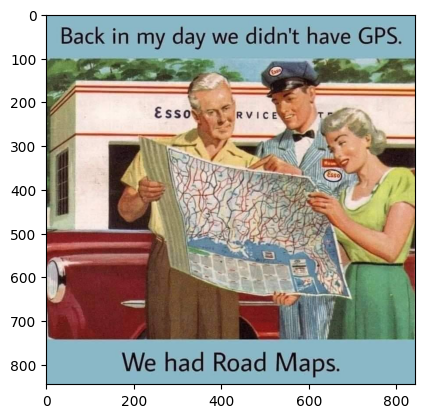

In [13]:
from PIL import Image
from pylab import *
im = array(Image.open('roadmap.jpg'))
imshow(im)
print('Please click 3 points')
# x = ginput(3)
print('you clicked:',x)
show()

This plots an image and waits for the user to click three times in the image region of the figure window. The coordinates [x, y] of the clicks are saved in a list x.

**Numpy**

This is a package for scientific computing with Python and it contains a number of useful concepts such as array objects for
representing vectors, matrices, images and much more) and linear algebra functions. The NumPy array object will be used in almost all examples throughout this book. The array object lets you do important operations such as matrix multiplication, transposition, solving equation systems, vector multiplication, and normalization, which are useful for doing things like aligning images, warping images, modeling variations, classifying images, grouping images etc.

**Array representation**

When we loaded images in the previous examples, we converted them to NumPy array objects with the array() call but didn’t mention what that means. Arrays in NumPy are multi-dimensional and can represent vectors, matrices, and images. An array is much like a list (or list of lists) but is restricted to having all elements of the same type. Unless specified on creation, the type will automatically be set depending on the data. The following example illustrates this for images:

In [14]:
im = array(Image.open('roadmap.jpg'))
print(im.shape)
print(im.dtype)
im = array(Image.open('roadmap.jpg').convert('L'),'f')
print(im.shape)
print(im.dtype)

(845, 843, 3)
uint8
(845, 843)
float32


The first tuple on each line is the shape of the image array (rows, columns, color channels), and the following string is the data type of the array elements. Images are usually encoded with unsigned 8-bit integers (uint8), so loading this image and converting to an array gives the type “uint8” in the first case. The second case does grayscale conversion and creates the array with the extra argument “f”. This is a short command for setting the type to floating point. For more data type options, see the literature. Note that the grayscale image has only two values in the shape tuple; obviously it has
no color information. Elements in the array are accessed with indexes. The value at coordinates i , j and color
channel k are accessed like this:

value = im[i,j,k]

Multiple elements can be accessed using array slicing. Slicing returns a view into the array specified by intervals. Here are some examples for a grayscale image:

im[i,:] = im[j,:] # set the values of row i with values from row j

im[:,i] = 100 # set all values in column i to 100

im[:100,:50].sum() # the sum of the values of the first 100 rows and 50 columns

im[50:100,50:100] # rows 50-100, columns 50-100 (100th not included)

im[i].mean() # average of row i

im[:,-1] # last column

im[-2,:] (or im[-2]) # second to last row

Note the example with only one index. If you only use one index, it is interpreted as the row index. Note also the last examples. Negative indices count from the last element backward. We will frequently use slicing to access pixel values, and it is an important concept to understand. There are many operations and ways to use arrays.We will introduce them as they are needed.

**Graylevel transforms**

After reading images to NumPy arrays, we can perform any mathematical operation we like on them. A simple example of this is to transform the graylevels of an image. Take any function f that maps the interval 0 . . . 255 (or, if you like, 0 . . . 1) to itself (meaning that the output has the same range as the input). Here are some examples:

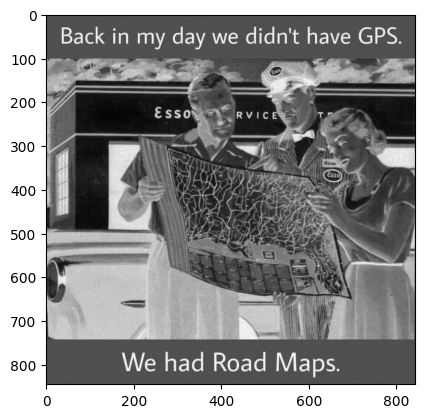

In [15]:
from PIL import Image
from numpy import *
im = array(Image.open('roadmap.jpg').convert('L'))
im2 = 255 - im # invert image
im3 = (100.0/255) * im + 100 # clamp to interval 100...200
im4 = 255.0 * (im/255.0)**2 # squared
imshow(im2)

The first example inverts the graylevels of the image, the second one clamps the intensities to the interval 100 . . . 200, and the third applies a quadratic function, which lowers the values of the darker pixels. You can check the minimum and maximum values of each image using im.min() and im.max().

**Histogram Equalization**

A very useful example of a graylevel transformis histogramequalization. This transform flattens the graylevel histogramof an image so that all intensities are as equally common as possible. This is often a good way to normalize image intensity before further processing and also a way to increase image contrast. The transform function is, in this case, a cumulative distribution function (cdf) of the pixel values in the image (normalized to map the range of pixel values to the desired
range).

Here’s how to do it. Add this function to the file imtools.py:

In [16]:
def histeq(im,nbr_bins=64):
  """ Histogram equalization of a grayscale image. """
  # get image histogram
  imhist,bins = histogram(im.flatten(),nbr_bins)
  cdf = imhist.cumsum() # cumulative distribution function
  cdf = 255 * cdf / cdf[-1] # normalize
  # use linear interpolation of cdf to find new pixel values
  im2 = interp(im.flatten(),bins[:-1],cdf)
  return im2.reshape(im.shape), cdf

The function takes a grayscale image and the number of bins to use in the histogram as input, and returns an image with equalized histogram together with the cumulative distribution function used to do the mapping of pixel values. Note the use of the last element (index -1) of the cdf to normalize it between 0 . . . 1. We try this on the grayscale version of our familiar image:

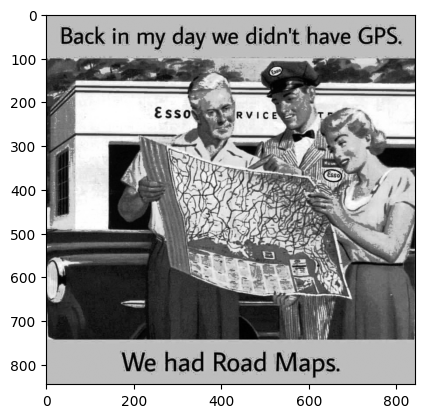

In [17]:
from PIL import Image
from numpy import *
im = array(Image.open('roadmap.jpg').convert('L'))
imh,cdf = histeq(im)
imshow(imh)

**Averaging**

Averaging images is a simple way of reducing image noise and is also often used for artistic effects. Computing an average image from a list of images is not difficult. Assuming the images all have the same size, we can compute the average of all those images by simply summing them up and dividing with the number of images. Consider the following function

In [18]:
def compute_average(imlist):
  """ Compute the average of a list of images. """
  # open first image and make into array of type float
  averageim = array(Image.open(imlist[0]), 'f')
  for imname in imlist[1:]:
    try:
      averageim += array(Image.open(imname))
    except:
      print( imname + '...skipped' )
  averageim /= len(imlist)
  # return average as uint8
  return array(averageim, 'uint8')

This includes some basic exception handling to skip images that can’t be opened. There is another way to compute average images using the mean() function. This requires all images to be stacked into an array andwill use lots of memory if there are many images. We will use this function in the next section.

**Principal Component Analysis (PCA)**

This technique (also known under several other names, cf. https://en.wikipedia.org/wiki/Principal_component_analysis) is useful for dimensionality reduction and it is optimal in the sense that it represents the variability of the processed data with as few dimensions as possible. Even a tiny 100x100 pixel grayscale image has 10,000 dimensions, and can be considered a point in a 10,000 dimensional space. A megapixel image has dimensions in the millions. With such high dimensionality, it is no surprise that dimensionality reduction comes handy in many computer vision applications. The projection matrix resulting from PCA can be seen as a change of coordinates to a coordinate system where the coordinates are in descending order of importance. To apply PCA on image data, the images need to be converted to a one-dimensional vector representation, for example using NumPy’s flatten() method. The flattened images are collected in a single matrix by stacking them, one row for each image. The rows are then centered relative to the mean image before the computation of the dominant directions. To find the principal components, singular value decomposition (SVD) is usually used, but if the dimensionality is high, there is a useful trick that can be used instead since the SVD computation will be very slow in that case. Here is an example code:

In [19]:
%matplotlib inline
from PIL import Image
from numpy import *
def pca(X):
    """ Principal Component Analysis
    input: X, matrix with training data stored as flattened arrays in rows
    return: projection matrix (V; with important dimensions first), variance and mean. """
    # get dimensions
    num_data,dim = X.shape
    # center data
    mean_X = X.mean(axis=0)
    X = X - mean_X
    if dim>num_data:
        # PCA - compact trick used
        M = dot(X,X.T) # covariance matrix
        e,EV = linalg.eigh(M) # eigenvalues and eigenvectors
        tmp = dot(X.T,EV).T # this is the compact trick
        V = tmp[::-1] # reverse since last eigenvectors are the ones we want S = sqrt(e)[::-1]
        # reverse since eigenvalues are in increasing order
        for i in range(V.shape[1]): V[:,i] /= S
    else:
        # PCA - SVD used
        U,S,V = linalg.svd(X)
        V = V[:num_data] # only makes sense to return the first num_data
        # return the projection matrix, the variance and the mean
    return V,S,mean_X

The above function first centers the data by subtracting the mean in each dimension. Then the eigenvectors corresponding to the largest eigenvalues of the covariance matrix are computed, either using a compact trick (https://math.stackexchange.com/questions/409239/compute-pca-with-this-useful-trick) or using SVD. Here we used the function range() which takes an integer n and returns a list of integers 0 . . . (n 1).

We now test this on an example of font images. The directory a_thumbs (located on the same drive and path as the lecture notebooks) contains small thumbnail images of the character "a" printed in different fonts and then scanned. The 2359 fonts are from a collection of freely available fonts2. Assuming that the filenames of these images are stored in a list, imlist, the principal components can be computed and shown:

In [20]:
from PIL import Image
from pylab import *
import glob

In [22]:
imlist = glob.glob('./a_thumbs/*jpg')
im = array(Image.open(imlist[0])) # open one image to get size
m,n = im.shape[0:2]
# get the size of the images
imnbr = len(imlist) # get the number of images

# create matrix to store all flattened images
immatrix = array([array(Image.open(im)).flatten() for im in imlist],'f')
# perform PCA
V,S,immean = pca(immatrix)

IndexError: list index out of range

In [ ]:
# show some images (mean and 7 first modes)
figure()
gray()
subplot(2,4,1)
imshow(immean.reshape(m,n))
axis('off')
for i in range(7):
    subplot(2,4,i+2)
    imshow(V[i].reshape(m,n))
    axis('off')

Note that the images need to be converted back from the one-dimensional representation using reshape(). Running the example should give eight images in one figure window like above. Here we used the PyLab function subplot() to place multiple plots in one window.